In [1]:
from importlib.metadata import version

pkgs = [
	"matplotlib",
	"numpy",
	"tiktoken",
	"torch",
	"tensorflow",
]

for p in pkgs:
	print(f"{p} version: {version(p)}")

matplotlib version: 3.10.6
numpy version: 1.26.4
tiktoken version: 0.12.0
torch version: 2.2.2
tensorflow version: 2.16.2


matplotlib version: 3.10.6
torch version: 2.2.2
tiktoken version: 0.12.0
[6109, 3626, 6100, 345]
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
torch.Size([2, 4, 50257])
Parameter containing:
tensor([[ 0.1262,  1.6740,  0.9943],
        [ 0.3404,  1.2790, -1.3698],
        [ 1.0055, -0.1564,  0.3283],
        [ 0.6466,  0.5826, -0.7743]], requires_grad=True)
tensor([[ 0.1262,  1.6740,  0.9943],
        [ 0.3404,  1.2790, -1.3698]], grad_fn=<EmbeddingBackward0>)
tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)
tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>) 
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)
tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)
Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBa

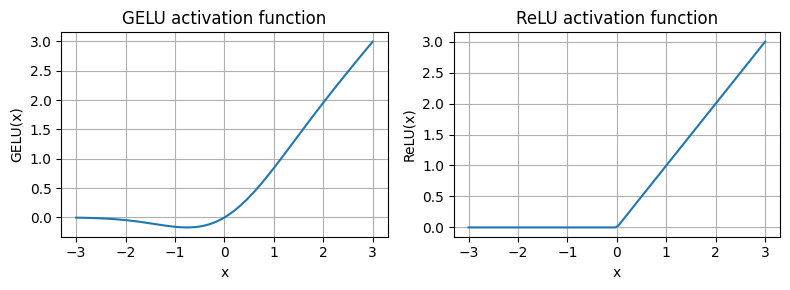

768
torch.Size([2, 3, 768])
layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041653171182
layers.3.0.weight has gradient mean of 0.001398873864673078
layers.4.0.weight has gradient mean of 0.005049646366387606
[('layers.0.0.weight', Parameter containing:
tensor([[-0.2354,  0.0191, -0.2867],
        [ 0.2177, -0.4919,  0.4232],
        [-0.4196, -0.4590, -0.3648]], requires_grad=True)), ('layers.0.0.bias', Parameter containing:
tensor([ 0.2615, -0.2133,  0.2161], requires_grad=True)), ('layers.1.0.weight', Parameter containing:
tensor([[-0.4900, -0.3503, -0.2120],
        [-0.1135, -0.4404,  0.3780],
        [-0.1362,  0.1853,  0.4083]], requires_grad=True)), ('layers.1.0.bias', Parameter containing:
tensor([0.1076, 0.1579, 0.5573], requires_grad=True)), ('layers.2.0.weight', Parameter containing:
tensor([[-0.2604,  0.1829, -0.2569],
        [ 0.4126,  0.4611, -0.532

In [2]:
import torch
import import_ipynb
import tiktoken
from chapter4 import GPTModel, generate_text_simple

In [3]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,    #1
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12, 
    "drop_rate": 0.1,       #2
    "qkv_bias": False
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [4]:
def text_to_token_ids(text, tokenizer):
	encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
	encoded_tensor = torch.tensor(encoded).unsqueeze(0)
	return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
	flat = token_ids.squeeze(0)
	decoded_text = tokenizer.decode(flat.tolist())
	return decoded_text

In [5]:
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
	model,
	idx = text_to_token_ids(start_context, tokenizer),
	max_new_tokens = 10,
	context_size = GPT_CONFIG_124M["context_length"]
	)
print("Output text: \n", token_ids_to_text(token_ids, tokenizer))
print(text_to_token_ids(start_context, tokenizer))

Output text: 
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren
tensor([[6109, 3626, 6100,  345]])


In [6]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

In [7]:
with torch.no_grad():
	logits = model(inputs)
probas = torch.softmax(logits,dim=-1)
print(probas.shape)
token_ids = torch.argmax(probas,dim=-1,keepdim=True)
print("Token IDs:\n", token_ids)

print(f"Targets batch 1: {token_ids_to_text(targets[0],tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(),tokenizer)}")

torch.Size([2, 3, 50257])
Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])
Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


In [8]:
text_idx = 0
target_probas_1 = probas[text_idx,[0,1,2],targets[text_idx]]
#target_probas_1 = probas[text_idx,torch.arange(probas.shape[1]),targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([    0.0001,     0.0000,     0.0000])
Text 2: tensor([    0.0000,     0.0001,     0.0000])


In [9]:
log_probas = torch.log(torch.cat((target_probas_1,target_probas_2)))
print(log_probas)

avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

neg_avg_log_probas = avg_log_probas * (-1)
print(neg_avg_log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])
tensor(-10.7940)
tensor(10.7940)


In [10]:
print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)

logits_flat = logits.flatten(0,1)
targets_flat = targets.flatten()
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

loss = torch.nn.functional.cross_entropy(logits_flat,targets_flat)
print(loss)
perplexity = torch.exp(loss)
print(perplexity)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])
Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])
tensor(10.7940)
tensor(48725.8203)


In [11]:
import os
import requests

In [12]:
file_path = "the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
	text_data = file.read()

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [13]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [14]:
import import_ipynb
from chapter2 import create_dataloader_v1

train_loader = create_dataloader_v1(
	txt = train_data,
	batch_size = 2,
	max_length = GPT_CONFIG_124M["context_length"],
	stride = GPT_CONFIG_124M["context_length"],
	drop_last=True,
	shuffle = True,
        num_workers=0
)

val_loader = create_dataloader_v1(
	txt = val_data,
	batch_size = 2,
	max_length = GPT_CONFIG_124M["context_length"],
	stride = GPT_CONFIG_124M["context_length"],
	drop_last=False,
	shuffle = False,
        num_workers=0
)

print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)




train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("\nTraining tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

torch version: 2.2.2
tiktoken version: 0.12.0
Total number of character: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married 
['Hello,', ' ', 'world.', ' ', 'This,', ' ', 'is', ' ', 'a', ' ', 'test.']
['Hello', ',', '', ' ', 'world', '.', '', ' ', 'This', ',', '', ' ', 'is', ' ', 'a', ' ', 'test', '.', '']
['Hello', ',', 'world', '.', 'This', ',', 'is', 'a', 'test', '.']
['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']
['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']
4690
['!', '"', "'", '(', ')', ',', '--', '.', ':', ';', '?', 'A', 'Ah', 'Among', 'And', 'Are', 'Arrt', 'As', 'At', 'Be', 'Begin', 'Burlington', 'But', 'By', 'Carlo', 'Chica

In [15]:
def calc_loss_batch(input_batch, target_batch,model,device):
	input_batch = input_batch.to(device)
	target_batch = target_batch.to(device)
	logits = model(input_batch)
	loss = torch.nn.functional.cross_entropy(logits.flatten(0,1),target_batch.flatten())

	return loss

def calc_loss_loader(data_loader, model, device, num_batches = None):
	total_loss = 0
	if len(data_loader) == 0:
		return float("nan")
	elif num_batches is None:
		num_batches = len(data_loader)
	else:
		num_batches = min(num_batches,len(data_loader))
	
	for i, (input_batch, targe_batch) in enumerate(data_loader):
		if i < num_batches:
			loss = calc_loss_batch(input_batch,targe_batch,model,device)
			total_loss += loss.item()
		else:
			break
	return total_loss/num_batches


In [16]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print(f"Using {device} device.")

model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader,model,device)
    val_loss = calc_loss_loader(val_loader,model,device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)


Using cpu device.
Training loss: 10.987583584255642
Validation loss: 10.98110580444336


In [17]:
def train_model_simple(model, train_loader, val_loader,optimizer, device, num_epochs,eval_freq,eval_iter, start_context,tokenizer):
	train_losses, val_losses, track_tokens_seen = [], [], []
	tokens_seen, global_step = 0 , -1

	for epoch in range(num_epochs):
		model.train()
		for input_batch, target_batch in train_loader:
			optimizer.zero_grad() # Reset loss gradients from previous batch iteration
			loss = calc_loss_batch(input_batch, target_batch,model,device)
			loss.backward() # Calculate loss gradients
			optimizer.step() # Update model weights using loss gradients
			tokens_seen += input_batch.numel()
			global_step += 1
		
			# Optional evaluation step
			if global_step % eval_freq == 0:
				train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
				train_losses.append(train_loss)
				val_losses.append(val_loss)
				track_tokens_seen.append(tokens_seen)
				print(f"Ep {epoch+1} (Step {global_step:06d}): "
				f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

		# Print a sample text after each epoch
		generate_and_print_sample(
			model, tokenizer,device, start_context
		)
	return train_losses, val_losses, track_tokens_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
	model.eval()
	with torch.no_grad():
		train_loss = calc_loss_loader(train_loader,model,device,num_batches=eval_iter)
		val_loss = calc_loss_loader(val_loader,model,device,num_batches=eval_iter)
	model.train()
	return train_loss, val_loss

def generate_and_print_sample(mode,tokenizer,device,start_context):
	model.eval()
	context_size = model.pos_emb.weight.shape[0]
	encoded = text_to_token_ids(start_context, tokenizer).to(device)
	with torch.no_grad():
		token_ids = generate_text_simple(model = model, idx = encoded, max_new_tokens=50, context_size=context_size)
	decoded_text = token_ids_to_text(token_ids,tokenizer)
	print(decoded_text.replace("\n", " "))  # Compact print format
	model.train()	

In [18]:
import time
start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(),lr=0.0004,weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
	model, train_loader, val_loader,optimizer, device, 
	num_epochs,eval_freq = 5, eval_iter = 5, 
	start_context="Every effort moves you", tokenizer=tokenizer
	)
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.783, Val loss 9.927
Ep 1 (Step 000005): Train loss 7.985, Val loss 8.335
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.753, Val loss 7.048
Ep 2 (Step 000015): Train loss 6.114, Val loss 6.573
Every effort moves you, and,, and, and,,,,, and, and,,,,,,,,,,,,,, and,,,, and,, and,,,,, and,,,,,,
Ep 3 (Step 000020): Train loss 5.525, Val loss 6.490
Ep 3 (Step 000025): Train loss 5.324, Val loss 6.387
Every effort moves you, and to the picture.                      "I, and the of the of the's the honour, and, and I had been, and I
Ep 4 (Step 000030): Train loss 4.761, Val loss 6.360
Ep 4 (Step 000035): Train loss 4.461, Val loss 6.258
Every effort moves you of the to the picture--as of the picture--as I had been " it was his " I was the     "I was his I had been the his pictures--and it the picture and I had been the picture of
Ep 5 (Step 000040): Train loss 3.833, Val loss 6.196
Every effort moves yo

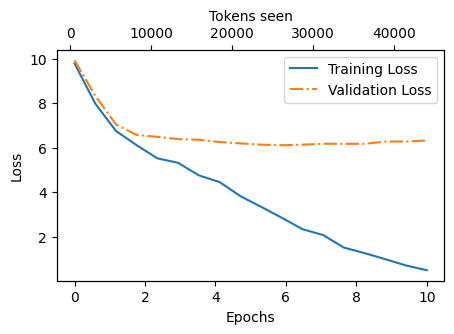

In [19]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
	fix, ax1 = plt.subplots(figsize = (5,3))

	ax1.plot(epochs_seen, train_losses, label = "Training Loss")
	ax1.plot(epochs_seen, val_losses, linestyle = "-.", label = "Validation Loss")
	ax1.set_xlabel("Epochs")
	ax1.set_ylabel("Loss")
	ax1.legend(loc = "upper right")
	ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

	ax2 = ax1.twiny()
	ax2.plot(tokens_seen,train_losses, alpha=0)
	ax2.set_xlabel("Tokens seen")

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [20]:
inference_device = torch.device("cpu")
model.to(inference_device)
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
	model,
	idx = text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
	max_new_tokens = 25,
	context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




In [21]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v : k for k,v in vocab.items()}
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)
probas = torch.softmax(next_token_logits, dim=0)
print(probas)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])
print(torch.multinomial(probas, num_samples=3,replacement=True))


tensor([    0.0609,     0.0016,     0.0001,     0.5721,     0.0034,     0.0001,
            0.0001,     0.3576,     0.0040])
forward
toward
tensor([3, 3, 7])


In [22]:
def print_sampled_tokens(probas):
	torch.manual_seed(123)
	#sample = [torch.multinomial(probas, num_samples=1).item() for _ in range(1_000)] 
	# torch.multinomial(probas, num_samples=1000, replacement=True).tolist()
	sample = torch.multinomial(probas, num_samples=1000, replacement=True)
	sampled_ids = torch.bincount(sample,minlength=len(probas))
	for i, freq in enumerate(sampled_ids):
		print(f"{freq} x {inverse_vocab[i]}")
		
print_sampled_tokens(probas)

64 x closer
3 x every
0 x effort
572 x forward
2 x inches
0 x moves
0 x pizza
356 x toward
3 x you


In [23]:
def softmax_with_temperature(logits,temperature):
	scaled_logits = logits / temperature
	return torch.softmax(scaled_logits, dim = 0)

temperatures = [1, 0.1, 5]  # Original, higher confidence, and lower confidence

# Calculate scaled probabilities
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]
for i in range(len(scaled_probas)):
	print("\n")
	print_sampled_tokens(scaled_probas[i])



64 x closer
3 x every
0 x effort
572 x forward
2 x inches
0 x moves
0 x pizza
356 x toward
3 x you


0 x closer
0 x every
0 x effort
990 x forward
0 x inches
0 x moves
0 x pizza
10 x toward
0 x you


157 x closer
70 x every
46 x effort
261 x forward
79 x inches
39 x moves
41 x pizza
210 x toward
97 x you


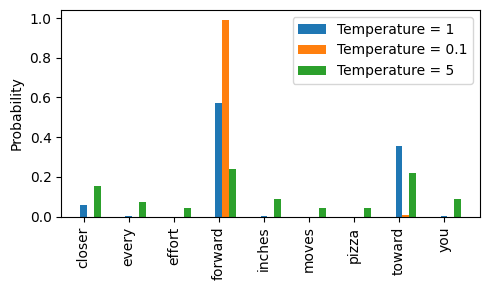

In [24]:
# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5,3))
for i, T in enumerate(temperatures):
	rects = ax.bar(x + i * bar_width, scaled_probas[i], 
                   bar_width, label=f'Temperature = {T}')

ax.set_ylabel("Probability")
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()



In [25]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits,top_k)

print("Top logits:", top_logits)
print("Top positions:", top_pos)

new_logits = torch.where(
	condition= next_token_logits < top_logits[-1],
	input=torch.tensor(float("-inf")),
	other=next_token_logits
)
print(new_logits)
#new_logits = torch.full_like( # create tensor containing -inf values
#	next_token_logits, -torch.inf
#)   
#new_logits[top_pos] = next_token_logits[top_pos] # copy top k values into the -inf tensor
#print(torch.full_like(next_token_logits,-torch.inf))
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)


Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])
tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])
tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [26]:
def generate(model, idx, max_new_tokens, context_size, temperature = 0.0, top_k = None, eos_id = None):
	for _ in range(max_new_tokens):
		idx_cond = idx[:,-context_size:]
		with torch.no_grad():
			logits = model(idx_cond)
		logits = logits[:,-1,:]

		if top_k is not None:
			top_logits, _ = torch.topk(logits,top_k,dim=-1)
			min_val = top_logits[:,-1]
			logits = torch.where(
				condition = logits < min_val,
				input = torch.tensor(float("-inf")).to(logits.device), #torch.full_like(logits, float("-inf"))
				other = logits
			)
		
		if temperature > 0 :
			logits = logits/temperature
			logits = logits - logits.max(dim=-1,keepdim= True).values
			probas = torch.softmax(logits,dim=-1)
			idx_next = torch.multinomial(probas,num_samples=1)
		else:
			idx_next = torch.argmax(logits, dim=-1, keepdim=True)

		if idx_next == eos_id:
			break
		idx = torch.cat((idx,idx_next) , dim = 1)
	return idx

In [27]:
torch.manual_seed(123)
token_ids = generate(
	model,
	idx = text_to_token_ids("Every effort moves you",tokenizer),
	max_new_tokens=15,
	context_size= GPT_CONFIG_124M["context_length"],
	top_k=25,
	temperature=1.4
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you know began to my surprise, a little it was the
"Ah enough


In [28]:
torch.save(model.state_dict(),"model.pth")
model = GPTModel(GPT_CONFIG_124M)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
else:
    device = torch.device("cpu")

model.load_state_dict(torch.load("model.pth", map_location=device, weights_only=True))
model.eval()

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
},
"model_and_optimizer.pth")

In [29]:
check_point = torch.load("model_and_optimizer.pth", map_location=device, weights_only=True)

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(check_point["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr = 0.0005, weight_decay=0.1)
optimizer.load_state_dict(check_point["optimizer_state_dict"])
model.train()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [30]:
import urllib.request

#file_name = "gpt2-small-124M.pth"
# file_name = "gpt2-medium-355M.pth"
# file_name = "gpt2-large-774M.pth"
# file_name = "gpt2-xl-1558M.pth"

#url = f"https://huggingface.co/rasbt/gpt2-from-scratch-pytorch/resolve/main/{file_name}"
#if not os.path.exists(file_name):
#    urllib.request.urlretrieve(url, file_name)
#   print(f"Downloaded to {file_name}")

url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x121e61370>)

In [31]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

2026-02-07 10:36:14.382124: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


In [32]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])
[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


In [33]:
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024})
NEW_CONFIG.update({"qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [34]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, "
                          "Right: {right.shape}"
        )
    return torch.nn.Parameter(torch.tensor(right))

In [35]:
import numpy as np

def load_weights_into_gpt(gpt, params):
	gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
	gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

	for b in range(len(params["blocks"])):
		q_w, k_w, v_w = np.split(
		(params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
		gpt.trf_blocks[b].att.W_query.weight = assign(
		gpt.trf_blocks[b].att.W_query.weight, q_w.T)
		gpt.trf_blocks[b].att.W_key.weight = assign(
		gpt.trf_blocks[b].att.W_key.weight, k_w.T)
		gpt.trf_blocks[b].att.W_value.weight = assign(
		gpt.trf_blocks[b].att.W_value.weight, v_w.T)

		q_b, k_b, v_b = np.split(
		(params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
		gpt.trf_blocks[b].att.W_query.bias = assign(
		gpt.trf_blocks[b].att.W_query.bias, q_b)
		gpt.trf_blocks[b].att.W_key.bias = assign(
		gpt.trf_blocks[b].att.W_key.bias, k_b)
		gpt.trf_blocks[b].att.W_value.bias = assign(
		gpt.trf_blocks[b].att.W_value.bias, v_b)

		gpt.trf_blocks[b].att.out_proj.weight = assign(
		gpt.trf_blocks[b].att.out_proj.weight, 
		params["blocks"][b]["attn"]["c_proj"]["w"].T)
		gpt.trf_blocks[b].att.out_proj.bias = assign(
		gpt.trf_blocks[b].att.out_proj.bias, 
		params["blocks"][b]["attn"]["c_proj"]["b"])

		gpt.trf_blocks[b].ff.layers[0].weight = assign(
		gpt.trf_blocks[b].ff.layers[0].weight, 
		params["blocks"][b]["mlp"]["c_fc"]["w"].T)
		gpt.trf_blocks[b].ff.layers[0].bias = assign(
		gpt.trf_blocks[b].ff.layers[0].bias, 
		params["blocks"][b]["mlp"]["c_fc"]["b"])
		gpt.trf_blocks[b].ff.layers[2].weight = assign(
		gpt.trf_blocks[b].ff.layers[2].weight, 
		params["blocks"][b]["mlp"]["c_proj"]["w"].T)
		gpt.trf_blocks[b].ff.layers[2].bias = assign(
		gpt.trf_blocks[b].ff.layers[2].bias, 
		params["blocks"][b]["mlp"]["c_proj"]["b"])

		gpt.trf_blocks[b].norm1.scale = assign(
		gpt.trf_blocks[b].norm1.scale, 
		params["blocks"][b]["ln_1"]["g"])
		gpt.trf_blocks[b].norm1.shift = assign(
		gpt.trf_blocks[b].norm1.shift, 
		params["blocks"][b]["ln_1"]["b"])
		gpt.trf_blocks[b].norm2.scale = assign(
		gpt.trf_blocks[b].norm2.scale, 
		params["blocks"][b]["ln_2"]["g"])
		gpt.trf_blocks[b].norm2.shift = assign(
		gpt.trf_blocks[b].norm2.shift, 
		params["blocks"][b]["ln_2"]["b"])

	gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
	gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
	gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

In [36]:
load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [37]:
torch.manual_seed(123)
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you toward an equal share for each vote plus half. Inequality is often not an accurate representation of human worth; to know the
